# Flow Matching

**Flow matching** is a deterministic transport method for generative modeling. It starts from a simple source distribution and learns a **velocity field** that carries samples toward the data distribution.

The method extends the path-based viewpoint introduced by diffusion models. Diffusion learns denoising or score-related quantities along a stochastic path. Flow matching learns transport velocities along a prescribed probability path, then generates samples by integrating an ODE from noise to data.

```{figure} ../assets/images/FM.png
:width: 78%
:align: center

A conceptual view of flow matching: a source distribution is connected to the data distribution through intermediate distributions, and a deterministic velocity field moves probability mass along that path.
```

The discussion begins with deterministic transport and then introduces conditional paths. The practical implementation uses **FashionMNIST**, matching the image-based examples used throughout the generative-model chapters.

```{important}
Flow matching separates **path design** from **field learning**. The path specifies how source samples are connected to data samples. The neural network learns the velocity field associated with that path.
```

## Deterministic Transport and Probability Paths

Let $\boldsymbol{x}(t)$ solve the ODE $\frac{d\boldsymbol{x}}{dt} = \boldsymbol{v}(\boldsymbol{x}(t), t)$, where $\boldsymbol{v}$ is a time-dependent velocity field. If the initial condition $\boldsymbol{x}(0)$ is random with density $p_0$, then the density $p_t$ of $\boldsymbol{x}(t)$ evolves according to
:::{math}
\partial_t p_t(\boldsymbol{x}) + \nabla_{\boldsymbol{x}} \cdot \big(p_t(\boldsymbol{x})\,\boldsymbol{v}(\boldsymbol{x}, t)\big) = 0.
:::

This is the **continuity equation**. It expresses conservation of probability mass under the deterministic flow.

```{prf:theorem} Continuity equation for deterministic flows
:label: thm-flow-continuity

Suppose $\boldsymbol{x}(t)$ solves
:::{math}
\frac{d\boldsymbol{x}}{dt} = \boldsymbol{v}(\boldsymbol{x}(t), t)
:::
and let $p_t$ denote the density of $\boldsymbol{x}(t)$. Under standard regularity assumptions,
:::{math}
\partial_t p_t(\boldsymbol{x}) + \nabla_{\boldsymbol{x}} \cdot \big(p_t(\boldsymbol{x})\,\boldsymbol{v}(\boldsymbol{x}, t)\big) = 0.
:::
```

```{prf:proof}
Let $\varphi$ be a smooth compactly supported test function. By the chain rule,
:::{math}
\frac{d}{dt}\mathbb{E}[\varphi(\boldsymbol{x}(t))]
=
\mathbb{E}\left[\nabla \varphi(\boldsymbol{x}(t))^\top \boldsymbol{v}(\boldsymbol{x}(t), t)\right].
:::
Writing the expectation against the density $p_t$ gives
:::{math}
\frac{d}{dt}\int \varphi(\boldsymbol{x}) p_t(\boldsymbol{x}) \, d\boldsymbol{x}
=
\int \nabla \varphi(\boldsymbol{x})^\top \boldsymbol{v}(\boldsymbol{x}, t) p_t(\boldsymbol{x}) \, d\boldsymbol{x}.
:::
Integrating by parts moves the gradient onto the flux term and yields
:::{math}
\int \varphi(\boldsymbol{x})
\left[
    \partial_t p_t(\boldsymbol{x}) + \nabla_{\boldsymbol{x}} \cdot \big(p_t(\boldsymbol{x})\,\boldsymbol{v}(\boldsymbol{x}, t)\big)
\right] d\boldsymbol{x} = 0.
:::
Since this holds for every test function $\varphi$, the bracketed quantity must vanish.
```


The physical picture is often clearer than the PDE. Imagine a colored dye moved by a fluid. The dye concentration at a location changes because the fluid carries mass in or out. Probability density behaves in the same way. Flow matching asks for the velocity field that moves mass from the source distribution to the data distribution.

The next ingredient is a **probability path** $(p_t)_{t \in [0,1]}$ with $p_0$ easy to sample and $p_1 = p_{\mathrm{data}}$. In practice, $p_0$ is often a standard Gaussian and $p_{\mathrm{data}}$ is the data distribution. Once the path is chosen, the modeling problem becomes learning a vector field whose induced flow pushes $p_0$ through the intermediate marginals and reaches $p_{\mathrm{data}}$ at time one.

The important conceptual separation is this: in flow matching, **path design** and **field learning** are different decisions. The path is a modeling choice. The vector field is the trainable object.

Diffusion begins from a known corruption process and learns how to reverse it. Flow matching defines a connection between source samples and data samples directly, then learns the velocity consistent with that connection. Both are path-based generative models. The predicted object changes: diffusion predicts noise or score-related quantities, while flow matching predicts **transport velocities**.

Let $\boldsymbol{x}_0 \sim p_0$ and $\boldsymbol{x}_1 \sim p_{\mathrm{data}}$. A simple conditional path is the linear interpolation
:::{math}
\boldsymbol{x}_t = (1-t)\boldsymbol{x}_0 + t\boldsymbol{x}_1.
:::
Conditionally on the endpoints, its instantaneous velocity is
:::{math}
\frac{d\boldsymbol{x}_t}{dt} = \boldsymbol{x}_1 - \boldsymbol{x}_0.
:::
This is already enough to generate a useful supervised target for learning.


```{admonition} Numerical Example: A Straight Conditional Path
:class: numerical-example

Let $\boldsymbol{x}_0 = (0,0)$ and $\boldsymbol{x}_1 = (4,2)$. Then the linear path is $\boldsymbol{x}_t = (4t, 2t)$. At time $t = 0.25$, the intermediate point is $(1, 0.5)$ and the conditional velocity is still $(4,2)$. In other words, the local instruction given to the model is: “if you are at $(1,0.5)$ at time $0.25$ for this endpoint pair, keep moving in the direction $(4,2)$.”

One such instruction is trivial. The power of flow matching comes from averaging many such local instructions across many endpoint pairs until a coherent global transport field emerges.
```


A single pair of endpoints defines a single path. The learned vector field must combine many such local instructions across overlapping regions of space and time. The model learns a global transport law from many endpoint pairs.

```{prf:theorem} Conditional flow matching target
:label: thm-cfm-regression

Let $(\boldsymbol{x}_0, \boldsymbol{x}_1)$ be sampled from a coupling of $p_0$ and $p_{\mathrm{data}}$. Let $\boldsymbol{x}_t$ be sampled from a conditional interpolation law $p_t(\boldsymbol{x} | \boldsymbol{x}_0, \boldsymbol{x}_1)$ with conditional velocity target $\boldsymbol{u}_t(\boldsymbol{x} | \boldsymbol{x}_0, \boldsymbol{x}_1)$. Then the minimizer of
:::{math}
\mathcal{L}_{CFM}(\theta)
=
\mathbb{E}\left[
    \|\boldsymbol{v}_\theta(\boldsymbol{x}_t, t) - \boldsymbol{u}_t(\boldsymbol{x}_t | \boldsymbol{x}_0, \boldsymbol{x}_1)\|_2^2
\right]
:::
is
:::{math}
\boldsymbol{v}^\star(\boldsymbol{x}, t)
=
\mathbb{E}\big[\boldsymbol{u}_t(\boldsymbol{x}_t | \boldsymbol{x}_0, \boldsymbol{x}_1) | \boldsymbol{x}_t = \boldsymbol{x}\big].
:::
```

```{prf:proof}
For fixed $(\boldsymbol{x}, t)$, the loss is a squared-error regression problem whose random target is the conditional velocity. The minimizer of squared error is the conditional expectation of that target given the input. Applying that fact pointwise yields the claim.
```


This theorem contains the practical heart of the method. Once the conditional path is chosen, generative learning becomes squared-error regression on velocity targets. Diffusion has a similar supervised-learning structure, with denoising targets in place of transport velocities.

## Flow Matching as Velocity Regression

Continuous normalizing flows also use an ODE to transform a source distribution into a target distribution. They are usually trained by maximum likelihood, which requires divergence terms and ODE integration inside the training objective. Flow matching keeps the ODE-based sampling viewpoint and trains through direct velocity regression.

The connection with diffusion is equally close. Diffusion begins with a stochastic path that has an associated deterministic **probability flow ODE**. Flow matching starts directly from a chosen deterministic transport target. Both families learn time-dependent neural fields that move mass from a simple source to the data distribution. The main difference lies in how the target field is constructed.

```{note}
The learned field is the **conditional expectation** of many local transport targets given the current state and time. This averaging is what turns many sampled endpoint pairs into one global vector field.
```

The straight-line path is the simplest choice. Other paths use **Gaussian perturbations** or **optimal-transport-inspired couplings** to change the local regression targets seen during training. This design choice matters because it changes the geometry of the velocity field.

A generative model includes a geometric choice. In VAEs that geometry appears through the latent variable and the KL regularizer. In diffusion it appears through the noising process. In flow matching it appears directly through the probability path.

## Guided Implementation: Rectified Flow on FashionMNIST

The practical example starts directly in image space. A noise tensor $\boldsymbol{x}_0$ with the same shape as a FashionMNIST image is paired with a data image $\boldsymbol{x}_1$. The rectified-flow path interpolates between them, and the neural network learns the velocity $\boldsymbol{x}_1 - \boldsymbol{x}_0$ that moves along that path.

The implementation shares the image-based structure of diffusion models: tensors, time embeddings, a compact U-Net-like backbone, and an MSE training target. The learned quantity is a **deterministic transport velocity**.

The dataset setup is the first practical choice.

FashionMNIST is a convenient bridge dataset because it is small enough to train quickly while still rich enough to produce recognizable structure. The images are scaled to $[-1,1]$ so that the data are centered like the Gaussian source. This keeps the interpolation path numerically balanced.

```{important}
The source and target live in the **same tensor space**. The noise sample $\boldsymbol{x}_0$ and the image $\boldsymbol{x}_1$ both have shape $1 \times 28 \times 28$. Flow matching learns motion directly in image space.
```

In [8]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)


In [9]:
image_batch_size = 128
image_size = 28
image_channels = 1
image_base_channels = 64
image_time_dim = 128
image_epochs = 35
image_lr = 2e-4
image_ode_steps = 100
num_workers = 0

project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"
CHECKPOINT_DIR = project_root / "artifacts" / "checkpoints"
RECTIFIED_FLOW_CHECKPOINT = CHECKPOINT_DIR / "fashionmnist_rectified_flow.pt"

image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

fashion_train = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=image_transform,
)

fashion_loader = DataLoader(
    fashion_train,
    batch_size=image_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)


The architecture below follows the compact U-Net family used in diffusion. Image-valued velocity prediction needs local spatial processing, multiscale context, and time conditioning at several depths.

In [10]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        factor = math.log(10000.0) / max(half_dim - 1, 1)
        frequencies = torch.exp(torch.arange(half_dim, device=t.device) * -factor)
        angles = t * frequencies.unsqueeze(0)
        emb = torch.cat([angles.sin(), angles.cos()], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class ImageResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_channels)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.activation = nn.SiLU()
        self.residual = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.activation(h)
        h = h + self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)
        return h + self.residual(x)


class ImageVelocityUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, time_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            TimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.input_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.down1 = ImageResidualBlock(base_channels, base_channels, time_dim)
        self.downsample1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.down2 = ImageResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.downsample2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.down3 = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.mid = ImageResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.up2 = ImageResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.up1 = ImageResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)
        x0 = self.input_conv(x)
        x1 = self.down1(x0, t_emb)
        x2 = self.downsample1(x1)
        x2 = self.down2(x2, t_emb)
        x3 = self.downsample2(x2)
        x3 = self.down3(x3, t_emb)
        x_mid = self.mid(x3, t_emb)
        x_up = self.upsample2(x_mid)
        x_up = torch.cat([x_up, x2], dim=1)
        x_up = self.up2(x_up, t_emb)
        x_up = self.upsample1(x_up)
        x_up = torch.cat([x_up, x1], dim=1)
        x_up = self.up1(x_up, t_emb)
        return self.output_conv(x_up)


image_flow_model = ImageVelocityUNet(
    in_channels=image_channels,
    base_channels=image_base_channels,
    time_dim=image_time_dim,
).to(device)
image_optimizer = torch.optim.AdamW(image_flow_model.parameters(), lr=image_lr, weight_decay=1e-4)


A useful way to read this architecture is to compare it with the diffusion U-Net. The convolutional backbone is similar because the input is still an image and the network still needs spatial hierarchy. The output has a different meaning: the final layer predicts the **velocity vector** that moves the current tensor through image space.

```{note}
The training target is simple because the path is simple. The model receives an intermediate tensor $\boldsymbol{x}_t$ and a time $t$, then predicts the local velocity needed to continue the transport.
```

In [11]:
def sample_image_path(x1):
    x0 = torch.randn_like(x1)
    t = torch.rand(x1.size(0), 1, 1, 1, device=x1.device)
    xt = (1.0 - t) * x0 + t * x1
    ut = x1 - x0
    return x0, x1, xt, ut, t.view(x1.size(0), 1)


def rectified_flow_loss(model, x1):
    _, _, xt, ut, t = sample_image_path(x1)
    pred = model(xt, t)
    return F.mse_loss(pred, ut)


This loss is one of the appealing parts of the method. Once the conditional path has been chosen, the image-scale objective is mean squared error. The modeling choices are concentrated in the path, the architecture, and the ODE sampler.

In [12]:
image_history = []

for epoch in tqdm(range(image_epochs), desc="Image rectified-flow epochs"):
    image_flow_model.train()
    running_loss = 0.0

    for x1, _ in tqdm(fashion_loader, desc="train", leave=False):
        x1 = x1.to(device)
        image_optimizer.zero_grad()
        loss = rectified_flow_loss(image_flow_model, x1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(image_flow_model.parameters(), max_norm=1.0)
        image_optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(fashion_loader)
    image_history.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d} | rectified-flow loss: {epoch_loss:.6f}")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": image_flow_model.state_dict(),
        "optimizer_state_dict": image_optimizer.state_dict(),
        "history": image_history,
        "config": {
            "image_size": image_size,
            "image_channels": image_channels,
            "image_base_channels": image_base_channels,
            "image_time_dim": image_time_dim,
            "image_ode_steps": image_ode_steps,
        },
    },
    RECTIFIED_FLOW_CHECKPOINT,
)
print(f"Saved rectified-flow checkpoint to {RECTIFIED_FLOW_CHECKPOINT}")


Image rectified-flow epochs:   0%|          | 0/35 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | rectified-flow loss: 0.360938


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | rectified-flow loss: 0.279894


...

Epoch 33 | rectified-flow loss: 0.224178


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 34 | rectified-flow loss: 0.223647


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 35 | rectified-flow loss: 0.224330
Saved rectified-flow checkpoint to c:\Users\tivog\deep-generative-models\artifacts\checkpoints\fashionmnist_rectified_flow.pt


The loss curve is interpretable in the same spirit as the diffusion MSE: lower values usually indicate better local velocity prediction. Sampling quality also depends on the solver and on how accurately the learned field behaves along generated trajectories.

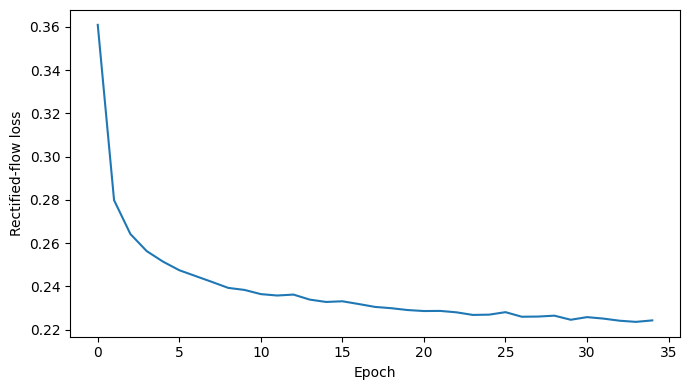

rectified-flow sampling:   0%|          | 0/100 [00:00<?, ?it/s]

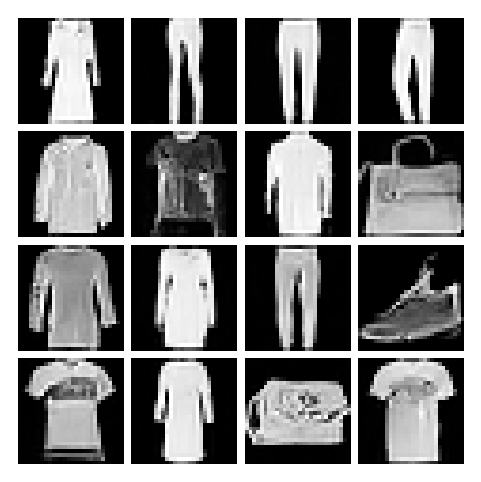

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(image_history)
plt.xlabel("Epoch")
plt.ylabel("Rectified-flow loss")
plt.tight_layout()
plt.show()


@torch.no_grad()
def sample_rectified_flow(model, n_samples=16, steps=image_ode_steps, show_progress=True):
    model.eval()
    x = torch.randn(n_samples, image_channels, image_size, image_size, device=device)
    dt = 1.0 / steps
    iterator = range(steps)
    if show_progress:
        iterator = tqdm(iterator, desc="rectified-flow sampling", leave=False)

    for i in iterator:
        t = torch.full((n_samples, 1), i / steps, device=device)
        v = model(x, t)
        # A midpoint step is a simple but meaningful upgrade over raw Euler.
        x_mid = x + 0.5 * dt * v
        t_mid = torch.full((n_samples, 1), (i + 0.5) / steps, device=device)
        x = x + dt * model(x_mid, t_mid)

    x = x.clamp(-1.0, 1.0)
    return 0.5 * (x + 1.0).cpu()


image_samples = sample_rectified_flow(image_flow_model, n_samples=16)
image_grid = utils.make_grid(image_samples, nrow=4, pad_value=1.0)
plt.figure(figsize=(6, 6))
plt.imshow(image_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.show()


Midpoint integration introduces the engineering issue behind continuous-time generators. After training the field, sample quality depends on the ODE solver as well as on the network. Generation therefore combines **local velocity prediction** with **global numerical integration**.

## Sampling, Evaluation, and Interpretation

At image scale, evaluation follows the same distribution-level logic used for the earlier model families. Real and generated samples are compared in a pretrained feature space. Both sets should use the same preprocessing and moderate metric batches. Caching the real features avoids repeated work during solver or variant comparisons.

```{warning}
FID and KID require enough generated samples and the same real-data preprocessing pipeline used by the other image models. A poor score can come from undertraining, weak path design, insufficient solver accuracy, or too few samples in the estimate.
```

```{note}
At image scale, flow matching resembles diffusion architecturally: image tensors, time embeddings, U-Net-like processing, and regression losses. The predicted quantity is a **transport velocity**.
```

In [14]:
def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_rectified_flow_fid_and_kid(model, real_loader, device, num_samples=1000, metric_batch_size=32):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    seen_real = 0
    for real_images, _ in tqdm(real_loader, desc="Rectified-flow real metrics", leave=False):
        remaining = num_samples - seen_real
        if remaining <= 0:
            break
        real_images = real_images[: min(metric_batch_size, remaining)].to(device)
        real_images = 0.5 * (real_images + 1.0)
        real_images = prepare_for_inception_metrics(real_images)
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen_real += real_images.size(0)

    generated = 0
    pbar = tqdm(total=num_samples, desc="rectified-flow fake metrics", leave=False)
    while generated < num_samples:
        batch_n = min(metric_batch_size, num_samples - generated)
        fake_images = sample_rectified_flow(
            model,
            n_samples=batch_n,
            steps=image_ode_steps,
            show_progress=False,
        ).to(device)
        fake_images = prepare_for_inception_metrics(fake_images)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = kid.compute()
    return {
        "fid": fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


rectified_flow_metrics = compute_rectified_flow_fid_and_kid(
    image_flow_model,
    fashion_loader,
    device,
    num_samples=1000,
    metric_batch_size=32,
)
print(rectified_flow_metrics)


c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Rectified-flow real metrics:   0%|          | 0/469 [00:00<?, ?it/s]

rectified-flow fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

{'fid': 30.816980599856606, 'kid_mean': 0.004778433125466108, 'kid_std': 0.0013600361999124289}


These numbers provide a quantitative distribution-level comparison. They should be read together with visual samples, solver analysis, and compute cost. A weak score can reflect architecture limits, undertraining, path design, or solver accuracy.

Flow matching expresses a central idea in modern generative modeling with unusual clarity: choose a geometric path from noise to data, learn the local motion along that path, and integrate the resulting field to generate samples.

In VAEs the geometry appears through latent variables and variational inference. In GANs it appears through the adversarial discrepancy. In diffusion it appears through the stochastic noising path. In flow matching it is written directly as a probability path with local velocity targets.